# Mejora de imagen y ecualización básica con `img1.jpg`

En este cuaderno se trabaja con una imagen distinta a la del archivo original para explorar cómo cambian el brillo, el contraste y la ecualización cuando la escena tiene zonas oscuras, luces intensas y bastante color.

## Objetivo

Analizar cómo diferentes ajustes de intensidad modifican la lectura visual de `img1.jpg` y comparar una mejora lineal con una ecualización aplicada sobre el canal `V` del espacio HSV.

## Resultados de aprendizaje

- ajustar brillo y contraste con una transformación lineal;
- observar qué detalles mejoran y cuáles se degradan con cada ajuste;
- aplicar ecualización global en grises y sobre el canal `V` en HSV;
- justificar qué estrategia resulta más conveniente para esta imagen.

## Módulos que vamos a usar

- `cv2`: para leer imágenes y transformar espacios de color.
- `matplotlib.pyplot`: para visualizar comparaciones.
- `pathlib.Path`: para construir rutas de manera clara.

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Construye la ruta de la imagen elegida para esta versión del cuaderno.
ruta_imagen = Path("Imagenes") / "img1.jpg"

# OpenCV lee por defecto en formato BGR.
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)

# Verifica que la imagen exista y se haya cargado correctamente.
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

# Convierte a RGB para mostrar la imagen con matplotlib sin alterar los colores.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

print(f"Dimensiones: {imagen_rgb.shape}")

Dimensiones: (2160, 3840, 3)


## 1. Imagen original

Antes de modificar nada, conviene observar la imagen base para identificar zonas oscuras, detalles finos y áreas que podrían saturarse si el ajuste es demasiado fuerte.

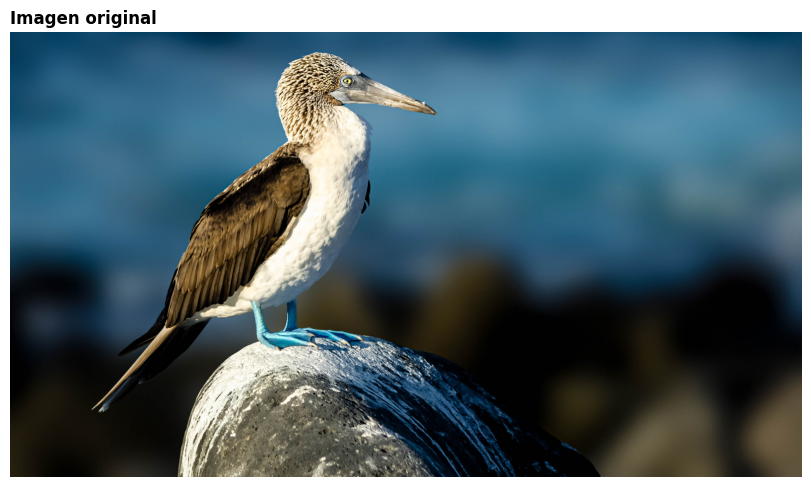

In [4]:
# Muestra la imagen original para tener una referencia visual antes de aplicar mejoras.
plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()

## 2. Ajuste lineal de brillo y contraste

La transformación lineal modifica las intensidades según la expresión `nuevo_valor = contraste * valor_original + brillo`. Es una estrategia simple y útil, pero no distingue entre información importante y zonas que pueden perder naturalidad.

In [5]:
# Define una función para ajustar brillo y contraste con una operación lineal.
def ajustar_brillo_contraste(imagen, brillo=0, contraste=1.0):
    """
    Ajusta brillo y contraste con una transformación lineal.

    brillo: desplaza los valores de intensidad.
    contraste: amplifica o reduce las diferencias entre tonos.
    """
    return cv2.convertScaleAbs(imagen, alpha=contraste, beta=brillo)

# Genera cuatro variantes simples para comparar el efecto de cada parámetro.
imagen_mas_brillo = ajustar_brillo_contraste(imagen_rgb, brillo=35, contraste=1.0)
imagen_menos_brillo = ajustar_brillo_contraste(imagen_rgb, brillo=-35, contraste=1.0)
imagen_mas_contraste = ajustar_brillo_contraste(imagen_rgb, brillo=0, contraste=1.35)
imagen_menos_contraste = ajustar_brillo_contraste(imagen_rgb, brillo=0, contraste=0.75)

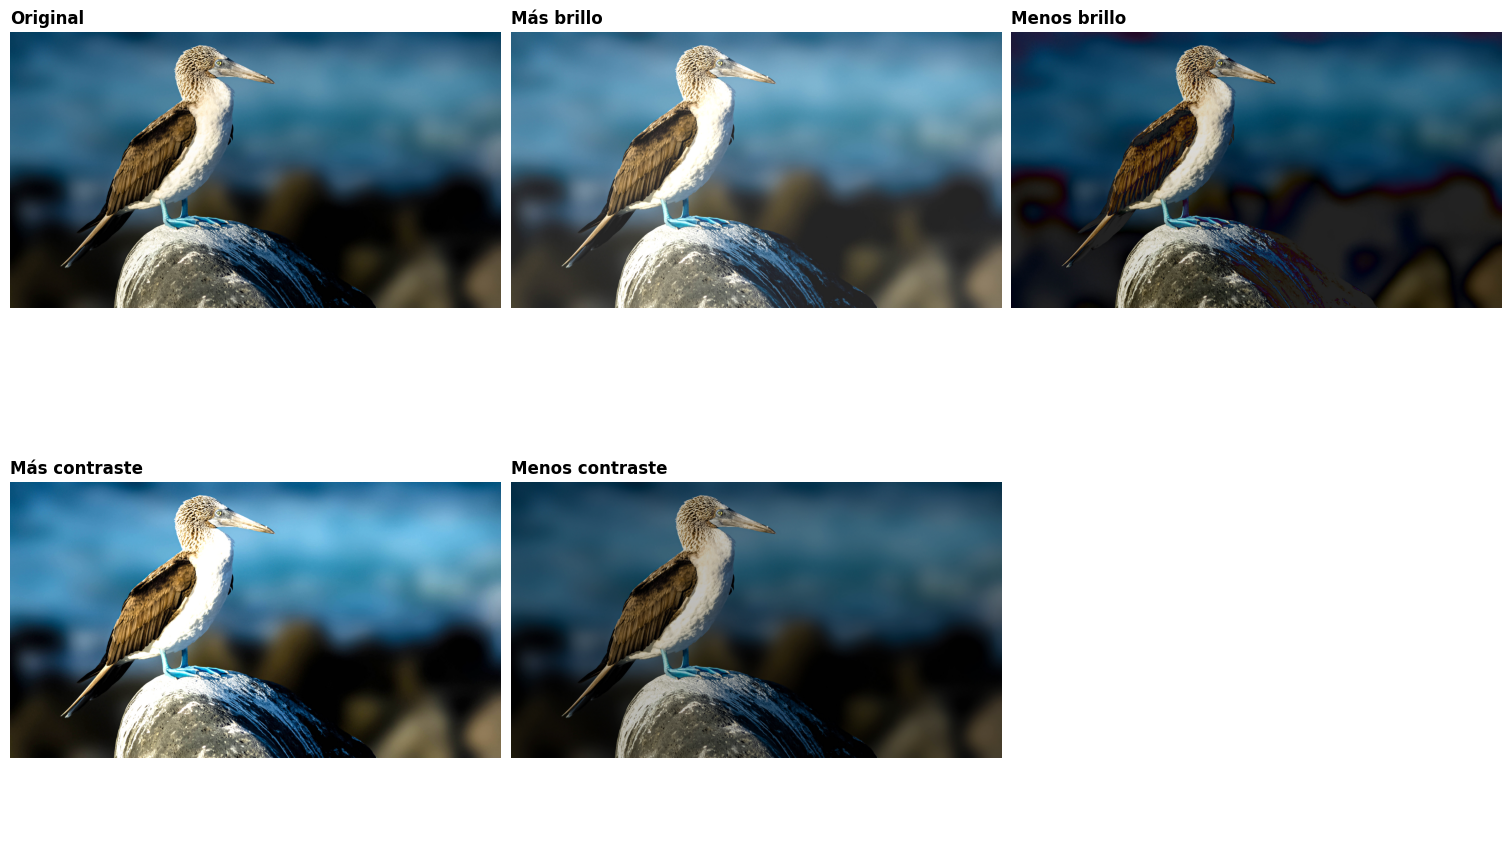

In [6]:
# Organiza la imagen original y sus variantes en una grilla para facilitar la comparación visual.
fig, ejes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

ejes[0, 0].imshow(imagen_rgb)
ejes[0, 0].set_title("Original", fontweight="bold", loc="left")
ejes[0, 0].axis("off")

ejes[0, 1].imshow(imagen_mas_brillo)
ejes[0, 1].set_title("Más brillo", fontweight="bold", loc="left")
ejes[0, 1].axis("off")

ejes[0, 2].imshow(imagen_menos_brillo)
ejes[0, 2].set_title("Menos brillo", fontweight="bold", loc="left")
ejes[0, 2].axis("off")

ejes[1, 0].imshow(imagen_mas_contraste)
ejes[1, 0].set_title("Más contraste", fontweight="bold", loc="left")
ejes[1, 0].axis("off")

ejes[1, 1].imshow(imagen_menos_contraste)
ejes[1, 1].set_title("Menos contraste", fontweight="bold", loc="left")
ejes[1, 1].axis("off")

ejes[1, 2].axis("off")
plt.show()

En esta imagen, subir el contraste vuelve más visibles algunas texturas del ave y de la roca, pero también puede endurecer las transiciones y volver demasiado intensas las luces del pecho.

## 3. Ecualización en escala de grises

La ecualización redistribuye los niveles de intensidad para aprovechar mejor el rango tonal disponible. En imágenes con contraste limitado, puede hacer más visibles ciertos detalles.

In [7]:
# Convierte la imagen a escala de grises y aplica ecualización del histograma
# para mejorar el contraste mediante una mejor distribución de las intensidades.
imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
imagen_gris_ecualizada = cv2.equalizeHist(imagen_gris)

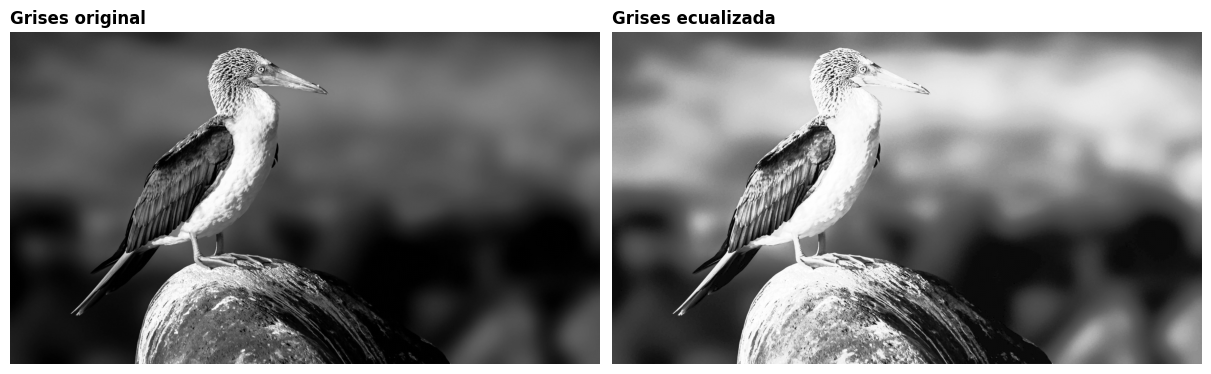

In [8]:
# Compara la imagen en grises original con la versión ecualizada para observar el cambio de contraste.
fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_gris, cmap="gray")
ejes[0].set_title("Grises original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(imagen_gris_ecualizada, cmap="gray")
ejes[1].set_title("Grises ecualizada", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

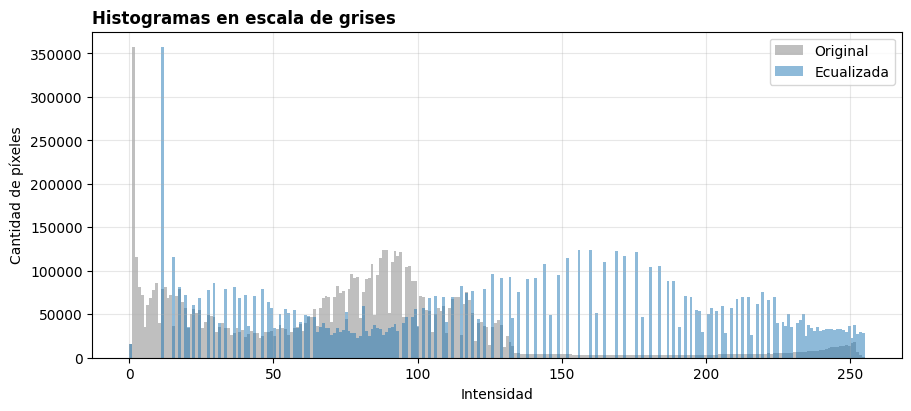

In [9]:
# Grafica los histogramas para ver cómo cambian las intensidades antes y después de ecualizar.
plt.figure(figsize=(9, 4), constrained_layout=True)
plt.hist(imagen_gris.ravel(), bins=256, alpha=0.5, label="Original", color="gray")
plt.hist(imagen_gris_ecualizada.ravel(), bins=256, alpha=0.5, label="Ecualizada", color="tab:blue")
plt.title("Histogramas en escala de grises", fontweight="bold", loc="left")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Mejorar solo el canal `V` en HSV

En lugar de modificar directamente los tres canales de color, esta estrategia ecualiza solo el canal de valor. Así se mejora la luminosidad y el contraste manteniendo mejor el tono y la saturación.

In [10]:
# Convierte a HSV, ecualiza solo el canal V y reconstruye la imagen en RGB.
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
canal_h, canal_s, canal_v = cv2.split(imagen_hsv)

canal_v_ecualizado = cv2.equalizeHist(canal_v)
imagen_hsv_mejorada = cv2.merge([canal_h, canal_s, canal_v_ecualizado])
imagen_mejorada_rgb = cv2.cvtColor(imagen_hsv_mejorada, cv2.COLOR_HSV2RGB)

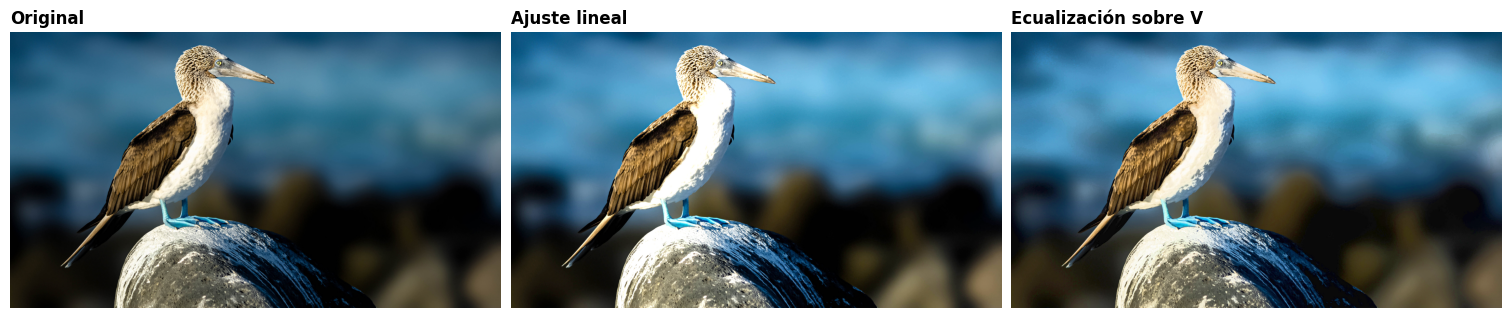

In [11]:
# Compara la imagen original con una versión mejorada mediante ajuste lineal
# y otra mejorada con ecualización sobre el canal V en HSV.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(imagen_mas_contraste)
ejes[1].set_title("Ajuste lineal", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_mejorada_rgb)
ejes[2].set_title("Ecualización sobre V", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

## 5. Resolución de la actividad

Ahora se prueban dos combinaciones distintas de `brillo` y `contraste` sobre la misma imagen para comparar qué detalles mejoran, qué partes se degradan y cuál estrategia conviene más en este caso.

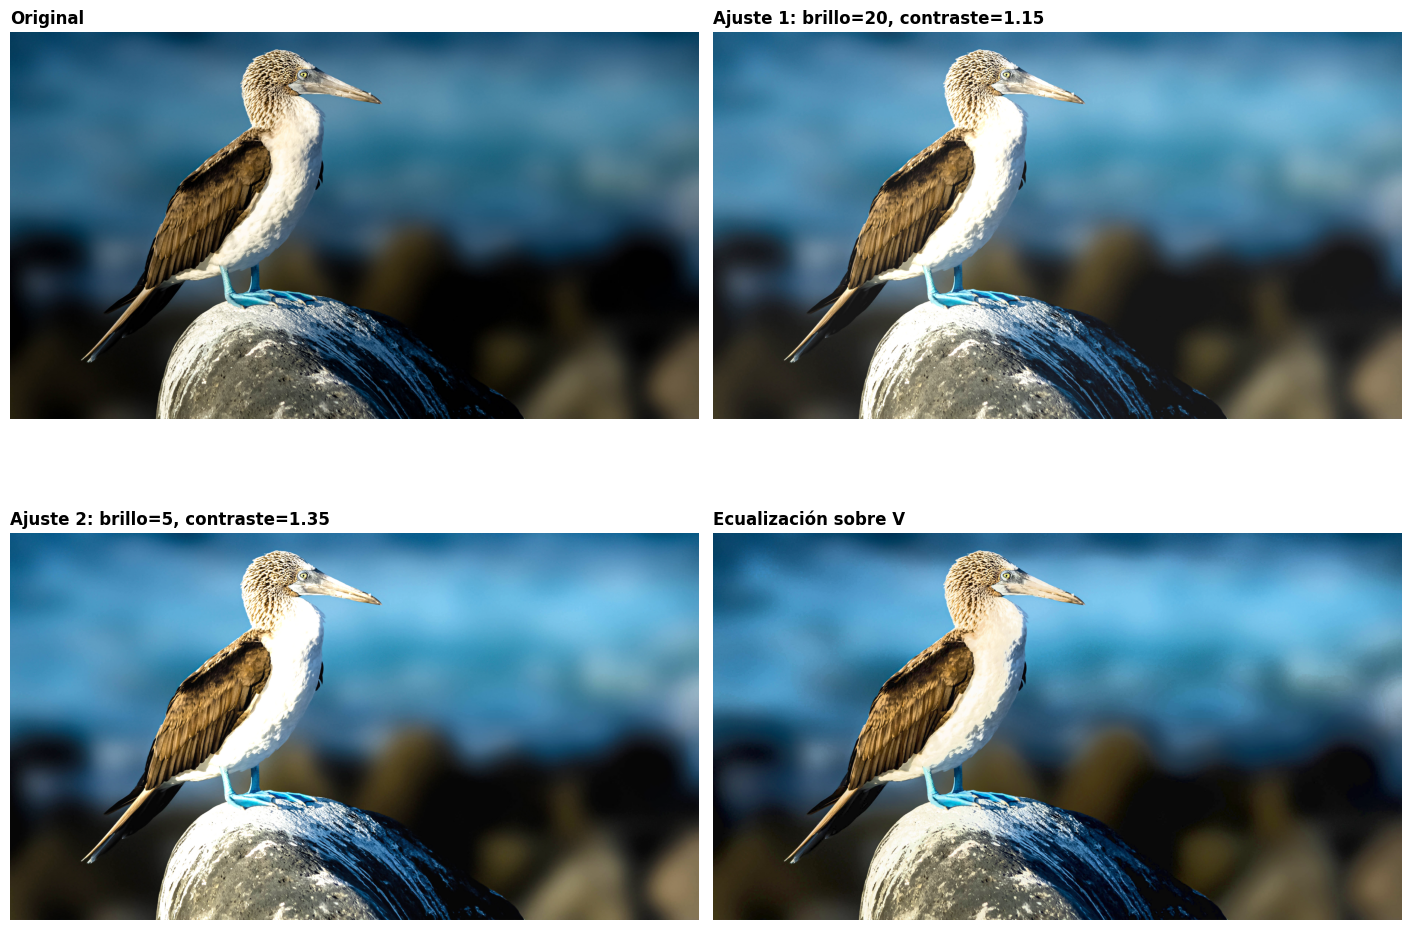

In [12]:
# Define dos ajustes lineales concretos para responder la consigna de manera comparativa.
ajuste_1 = ajustar_brillo_contraste(imagen_rgb, brillo=20, contraste=1.15)
ajuste_2 = ajustar_brillo_contraste(imagen_rgb, brillo=5, contraste=1.35)

# Reutiliza la versión ecualizada sobre V para contrastarla con los ajustes lineales.
fig, ejes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

ejes[0, 0].imshow(imagen_rgb)
ejes[0, 0].set_title("Original", fontweight="bold", loc="left")
ejes[0, 0].axis("off")

ejes[0, 1].imshow(ajuste_1)
ejes[0, 1].set_title("Ajuste 1: brillo=20, contraste=1.15", fontweight="bold", loc="left")
ejes[0, 1].axis("off")

ejes[1, 0].imshow(ajuste_2)
ejes[1, 0].set_title("Ajuste 2: brillo=5, contraste=1.35", fontweight="bold", loc="left")
ejes[1, 0].axis("off")

ejes[1, 1].imshow(imagen_mejorada_rgb)
ejes[1, 1].set_title("Ecualización sobre V", fontweight="bold", loc="left")
ejes[1, 1].axis("off")

plt.show()

### Respuestas

1. Con el `ajuste 1` mejora la visibilidad de las plumas del ave y parte de la textura de la roca, porque levanta un poco las sombras sin alterar demasiado la escena. Con el `ajuste 2` también se marcan más los contornos, pero de manera más agresiva.
2. En el `ajuste 2`, el pecho blanco del ave y algunas zonas iluminadas de la roca empiezan a perder naturalidad, porque el contraste alto empuja varios tonos hacia extremos y endurece las transiciones.
3. Para esta imagen prefiero la `ecualización sobre V`, porque mejora los detalles en sombras y medios tonos manteniendo mejor los colores originales. El ajuste lineal sirve para una corrección rápida, pero si se fuerza demasiado puede quemar luces y dar un resultado menos natural.

## Cierre

La mejora de imagen no consiste solo en hacer que todo se vea más brillante o más contrastado. Lo importante es evaluar qué información se vuelve más visible y qué parte de la escena se distorsiona. En `img1.jpg`, la ecualización sobre `V` resulta una opción más equilibrada para conservar la apariencia general y, al mismo tiempo, recuperar detalle.